In [1]:
import sys
import time
import random

import cv2
from PIL import Image
from itertools import combinations, permutations
from random import shuffle

import numpy as np
import matplotlib.pyplot as plt
import pyift.pyift as ift

## Find minimum bounding box of latent and crop images in same region

In [29]:
imgA = np.array(Image.open('../outputs/teste/registered_images/imageA.png'),dtype = np.int32)
imgB = np.array(Image.open('../outputs/teste/registered_images/imageB.png'), dtype = np.int32)

print(imgA.shape)
print(imgB.shape)

fig, ax = plt.subplots(nrows = 1, ncols = 2)
ax[0].imshow(imgA, cmap = 'gray')
ax[1].imshow(imgB, cmap = 'gray')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/teste/registered_images/imageA.png'

In [56]:
x_cords, y_cords = np.where(teste == 255)
x_cords

array([  0,   0,   0, ..., 145, 145, 145])

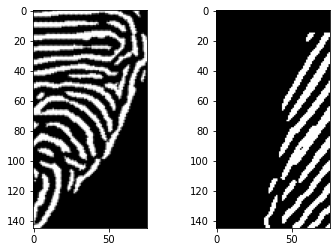

In [53]:
teste = np.where(imgA == 255, 255,0)
xmin = np.min(np.where(teste==255)[0])
xmax = np.max(np.where(teste==255)[0])
ymin = np.min(np.where(teste==255)[1])
ymax = np.max(np.where(teste==255)[1])

fig, ax = plt.subplots(nrows = 1, ncols = 2)
ax[0].imshow(imgA[xmin:xmax, ymin:ymax], cmap = 'gray')
ax[1].imshow(imgB[xmin:xmax, ymin:ymax], cmap = 'gray')
plt.show()

In [47]:
print(xmin, xmax, ymin, ymax)

0 323 94 298


In [38]:
iftImageA = ift.CreateImageFromNumPy(imgA, False)
iftImageB = ift.CreateImageFromNumPy(imgB, False)
mask = np.ones((imgA.shape), dtype = np.int32)
iftMask = ift.CreateImageFromNumPy(mask, False)
A = ift.Circular(3.5)
iftbin = ift.BelowAdaptiveThreshold(iftImageA, None, A, 0.99, 1, 255)

In [39]:
teste = iftbin.AsNumPy()

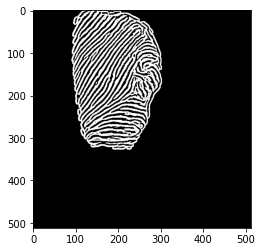

In [40]:
plt.imshow(teste, cmap ='gray')

In [157]:
latent_mnt_file    = '../input_samples/basep_mnts/1-104930526.mnt'
reference_mnt_file = '../input_samples/basep_mnts/1-61386113.mnt' 

def read_mnt(mnt_file):
    with open(mnt_file, 'r') as fp:
            mnts = fp.readlines()[2:]
    mnts = [tuple([int(i) for i in item.strip().split(' ')[:2]]) for item in mnts]
    return mnts

latent_mnts    = read_mnt(latent_mnt_file)
reference_mnts = read_mnt(reference_mnt_file)
reference_mnts = reference_mnts[:len(latent_mnts)]
# reference_mnts = [(item,(random.randint(0,512), random.randint(0,512))) for item in  reference_mnts]
# reference_mnts = [tuple([item]) for item in  reference_mnts]



In [130]:
from itertools import product
def cartesian_product(arr1, arr2):
    return list(product(arr1, arr2))

r = []
for item in reference_mnts:
    r += cartesian_product(latent_mnts, item)

In [158]:
homologous_points = list(zip(latent_mnts, reference_mnts))
homologous_pairs  = [comb for comb in combinations(homologous_points, 2)]

In [159]:
print('latent mnts: ', len(latent_mnts))
print('reference mnts: ', len(reference_mnts))
print('homologous_pairs: ', len(homologous_pairs))
# print('homologous_points: ', homologous_points[:2])
#print('homologous_pairs: ', homologous_pairs[:2])


latent mnts:  30
reference mnts:  30
homologous_pairs:  435


In [141]:
teste = []
for i in range(len(latent_mnts)):
    for j in range(len(reference_mnts[i])):
        teste.append((latent_mnts[i], reference_mnts[i][j]))

In [161]:
print('latent mnts: ', latent_mnts[:2])
print('reference mnts: ', reference_mnts[:2])
# print('teste: ', teste[:2])
print('homologous_points: ', homologous_points[:2])
print('homologous_pairs: ', homologous_pairs[:2])


latent mnts:  [(250, 306), (234, 322)]
reference mnts:  [(134, 106), (187, 220)]
homologous_points:  [((250, 306), (134, 106)), ((234, 322), (187, 220))]
homologous_pairs:  [(((250, 306), (134, 106)), ((234, 322), (187, 220))), (((250, 306), (134, 106)), ((196, 324), (330, 187)))]


In [162]:
for pair in homologous_pairs:
    ((x1,y1), (X1,Y1)), ((x2, y2), (X2,Y2)) = pair
    print(x1, y1, X1, Y1, x2, y2, X2, Y2)

250 306 134 106 234 322 187 220
250 306 134 106 196 324 330 187
250 306 134 106 241 150 265 249
250 306 134 106 172 243 226 89
250 306 134 106 254 257 174 163
250 306 134 106 197 219 211 203
250 306 134 106 269 309 169 58
250 306 134 106 261 330 219 164
250 306 134 106 210 196 117 237
250 306 134 106 169 161 73 206
250 306 134 106 221 354 171 219
250 306 134 106 307 189 97 154
250 306 134 106 242 339 308 265
250 306 134 106 210 373 233 230
250 306 134 106 237 253 353 117
250 306 134 106 186 210 259 274
250 306 134 106 282 306 337 274
250 306 134 106 179 212 324 70
250 306 134 106 301 211 268 92
250 306 134 106 194 356 346 300
250 306 134 106 293 357 206 394
250 306 134 106 317 165 314 236
250 306 134 106 194 378 365 217
250 306 134 106 194 102 324 124
250 306 134 106 300 206 91 68
250 306 134 106 314 365 154 235
250 306 134 106 290 294 140 267
250 306 134 106 301 282 394 235
250 306 134 106 251 117 156 165
234 322 187 220 196 324 330 187
234 322 187 220 241 150 265 249
234 322 187 220 

### RANSAC modificado - match file

In [8]:
# Minutia files
latent_mnt_file    = '../input_samples/sample_mnts/1-104930526.mnt'
reference_mnt_file = '../input_samples/sample_mnts/1-61386113.mnt'

def read_mnt(mnt_file):
    with open(mnt_file, 'r') as fp:
            mnts = fp.readlines()[2:]
    mnts = [tuple([int(i) for i in item.strip().split(' ')[:2]]) for item in mnts]
    return mnts

latent_mnts    = read_mnt(latent_mnt_file)
reference_mnts = read_mnt(reference_mnt_file)


In [9]:
# Match list files
match_list_folder = '../input_samples/sample_matches_list/'
match_list_files = os.listdir(match_list_folder)

match_sample = '../input_samples/sample_matches_list/1-104930526_1-61386113.txt'

def read_match_list(match_list):
    with open(match_list, 'r') as fp:
        matches = fp.readlines()
    matches = [tuple(int(i) for i in item.strip().split()) for item in matches]
    return matches

matches = read_match_list(match_sample) # matches format: index of latent_mnts, followed by 4 indexes of reference_mnts


In [62]:
matches_idx = [i for i in range(len(matches))]
# Generating every line (pair combination) in latent minutias
latent_pairs    = [comb for comb in combinations(matches_idx, 2)]

def get_latent_point_from_match_idx(match_idx, matches, latent_mnts):
    return latent_mnts[matches[match_idx][0]]

def get_ref_candidates_points_from_match_idx(match_idx, matches, reference_mnts):
    return [reference_mnts[i] for i in matches[match_idx][1:]]


def get_candidates_combinations(mnt1_candidates, mnt2_candidates):
    unique_combinations = []
    for pt1 in mnt1_candidates:
        for pt2 in mnt2_candidates:
            unique_combinations.append((pt1, pt2))

    return unique_combinations

for latent_pair in latent_pairs: # this accounts for every line of minutia in latent image
    l1, l2 = latent_pair
    x1, y1 = get_latent_point_from_match_idx(l1, matches, latent_mnts)
    x2, y2 = get_latent_point_from_match_idx(l2, matches, latent_mnts)

    a = get_ref_candidates_points_from_match_idx(l1, matches, reference_mnts)
    b = get_ref_candidates_points_from_match_idx(l2, matches, reference_mnts)

    # print(a)
    # print(b)
    #print(f'({x1},{y1})', f'({x2},{y2})')
    # this accounts for every line of candidates for these specific minutias
    candidate_combs = get_candidates_combinations(a, b)

    for R1,R2 in candidate_combs:
        #print(R1,R2)
        X1,Y1 = R1
        X2,Y2 = R2
        print(f'({X1},{Y1})', f'({X2},{Y2})')

        # X1, Y1 = reference_mnts[R1]
        # X2, Y2 = reference_mnts[R2]
        # idx1, idx2 = comb
        # R1 = reference_mnts[idx1]
        # R2 = reference_mnts[idx2]
        # print('\t', (X1,Y1), (X2,Y2))

(97,154) (122,123)
(97,154) (313,236)
(97,154) (307,266)
(97,154) (173,163)
(82,235) (122,123)
(82,235) (313,236)
(82,235) (307,266)
(82,235) (173,163)
(333,273) (122,123)
(333,273) (313,236)
(333,273) (307,266)
(333,273) (173,163)
(331,187) (122,123)
(331,187) (313,236)
(331,187) (307,266)
(331,187) (173,163)
(97,154) (157,166)
(97,154) (141,265)
(97,154) (140,373)
(97,154) (222,86)
(82,235) (157,166)
(82,235) (141,265)
(82,235) (140,373)
(82,235) (222,86)
(333,273) (157,166)
(333,273) (141,265)
(333,273) (140,373)
(333,273) (222,86)
(331,187) (157,166)
(331,187) (141,265)
(331,187) (140,373)
(331,187) (222,86)
(97,154) (116,121)
(97,154) (364,213)
(97,154) (345,300)
(97,154) (267,92)
(82,235) (116,121)
(82,235) (364,213)
(82,235) (345,300)
(82,235) (267,92)
(333,273) (116,121)
(333,273) (364,213)
(333,273) (345,300)
(333,273) (267,92)
(331,187) (116,121)
(331,187) (364,213)
(331,187) (345,300)
(331,187) (267,92)
(97,154) (133,106)
(97,154) (331,187)
(97,154) (373,269)
(97,154) (261,2

In [40]:
matches[latent_pairs[0][0]][1:]

(21, 65, 24, 16)

(0, 0, 16, 17, 18)

In [14]:
latent_mnts

[(250, 306),
 (197, 322),
 (234, 322),
 (268, 309),
 (242, 337),
 (221, 353),
 (212, 371),
 (236, 257),
 (253, 253),
 (266, 326),
 (282, 308),
 (211, 196),
 (299, 188),
 (172, 244),
 (217, 387),
 (197, 220),
 (180, 212),
 (169, 161),
 (186, 210),
 (194, 355),
 (242, 154)]